1.构建数据集

In [23]:
import math
import copy
import torch


def make_moons(n_samples=1000, shuffle=True,noise=None):
    n_samples_out = n_samples//2
    n_samples_in = n_samples - n_samples_out
    #生成两个类别的数据
    outer_circ_x = torch.cos(torch.linspace(0, math.pi, n_samples_out))
    outer_circ_y = torch.sin(torch.linspace(0, math.pi, n_samples_out))
    
    inner_circ_x = 1- torch.cos(torch.linspace(0, math.pi, n_samples_in))
    inner_circ_y = 0.5- torch.sin(torch.linspace(0, math.pi, n_samples_in))
    
    print('outer_circ_x.shape:',outer_circ_x.shape,'outer_circ_y.shape:',outer_circ_y.shape)
    print('outer_circ_x',outer_circ_x[:10])
    print('inner_circ_x.shape:',inner_circ_x.shape,'inner_circ_y.shape:',inner_circ_y.shape)
    print('inner_circ_x',inner_circ_x[:10])
    # 所有数据拼装
    concat_x = torch.cat([outer_circ_x, inner_circ_x])
    print('concat_x',concat_x.shape,'concat_x',concat_x[:10])
    concat_y = torch.cat([outer_circ_y, inner_circ_y])
    # 生成y标签
    X = torch.stack([concat_x, concat_y], dim=1)
    print(X.shape)
    y = torch.cat([torch.zeros(n_samples_out), torch.ones(n_samples_in)]).long()
    
    #样本打乱
    if shuffle:
        perm = torch.randperm(n_samples)
        X, y = X[perm], y[perm]
    
    if noise is not None:
        X += torch.randn(X.shape)*noise
        
    print('X',X[:5])
    print('y',y[:5])
    return X, y
        

outer_circ_x.shape: torch.Size([500]) outer_circ_y.shape: torch.Size([500])
outer_circ_x tensor([1.0000, 1.0000, 0.9999, 0.9998, 0.9997, 0.9995, 0.9993, 0.9990, 0.9987,
        0.9984])
inner_circ_x.shape: torch.Size([500]) inner_circ_y.shape: torch.Size([500])
inner_circ_x tensor([0.0000e+00, 1.9789e-05, 7.9274e-05, 1.7834e-04, 3.1710e-04, 4.9543e-04,
        7.1341e-04, 9.7096e-04, 1.2681e-03, 1.6049e-03])
concat_x torch.Size([1000]) concat_x tensor([1.0000, 1.0000, 0.9999, 0.9998, 0.9997, 0.9995, 0.9993, 0.9990, 0.9987,
        0.9984])
torch.Size([1000, 2])
X tensor([[ 0.9943, -1.5630],
        [ 0.2370,  0.2693],
        [-0.9243,  1.1459],
        [ 0.3442,  0.2164],
        [-0.0796,  1.1157]])
y tensor([1, 1, 0, 1, 0])
outer_circ_x.shape: torch.Size([500]) outer_circ_y.shape: torch.Size([500])
outer_circ_x tensor([1.0000, 1.0000, 0.9999, 0.9998, 0.9997, 0.9995, 0.9993, 0.9990, 0.9987,
        0.9984])
inner_circ_x.shape: torch.Size([500]) inner_circ_y.shape: torch.Size([500])
i

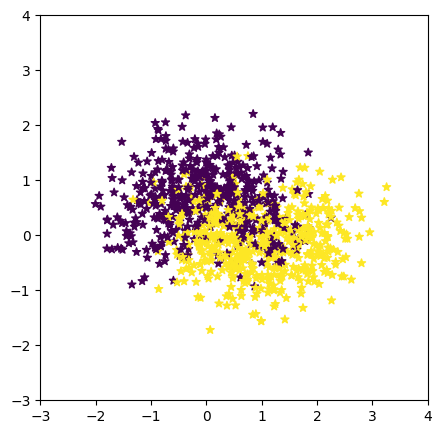

In [27]:
n_samples = 1000
X, y = make_moons(n_samples=n_samples,shuffle=True,noise=0.5)
make_moons(n_samples=1000)
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
plt.scatter(x=X[:,0].tolist(),y=X[:,1].tolist(),marker='*',c=y.tolist())
plt.xlim(-3,4)
plt.ylim(-3,4)
plt.savefig('linear-dataset-vis.pdf')
plt.show()


拆分训练集、验证集和测试集

In [29]:
num_train = 640
num_dev = 160
num_test = 200
X_train,y_train = X[:num_train],y[:num_train]
X_dev,y_dev = X[num_train:num_train+num_dev],y[num_train:num_train+num_dev]
X_test,y_test = X[num_train+num_dev:],y[num_train+num_dev:]

y_train = y_train.reshape([-1,1])
y_dev = y_dev.reshape([-1,1])
y_test = y_test.reshape([-1,1])

print(X_train.shape,y_train.shape)
print(X_train[:5],y_train[:5])
print(X_dev.shape,y_dev.shape)
print(X_test.shape,y_test.shape)


torch.Size([640, 2]) torch.Size([640, 1])
tensor([[ 0.9943, -1.5630],
        [ 0.2370,  0.2693],
        [-0.9243,  1.1459],
        [ 0.3442,  0.2164],
        [-0.0796,  1.1157]]) tensor([[1],
        [1],
        [0],
        [1],
        [0]])
torch.Size([160, 2]) torch.Size([160, 1])
torch.Size([200, 2]) torch.Size([200, 1])


定义logistic函数模型

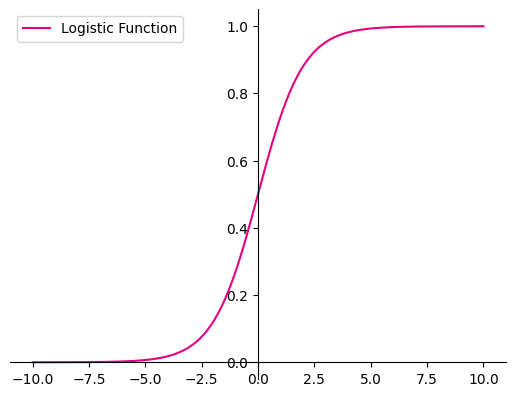

In [32]:
def logistic(x):
    return 1/(1+torch.exp(-x))

x = torch.linspace(-10,10,10000)
plt.figure()
plt.plot(x.tolist(),logistic(x).tolist(),color="#e4007f", label="Logistic Function")
ax = plt.gca()
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.spines['left'].set_position(('data',0))
ax.spines['bottom'].set_position(('data',0))

plt.legend()
plt.savefig('linear-logistic.pdf')
plt.show()